In [2]:
%pip install pandas numpy scikit-learn matplotlib seaborn statsmodels imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print('Libraries loaded successfully.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully.


In [3]:
df = pd.read_csv('../data/collisions_clean.csv', parse_dates=['CRASH DATE'])

print(f'Dataset: {len(df):,} records, {df.shape[1]} columns')
print(f'Date range: {df["CRASH DATE"].min().date()} to {df["CRASH DATE"].max().date()}')
df.head(3)

Dataset: 375,025 records, 29 columns
Date range: 2022-02-03 to 2026-01-30


,CRASH DATE,year,month,day_of_week,hour,is_weekend,season,BOROUGH,ZIP CODE,LATITUDE,...,total_casualties,severity,has_injury,has_fatality,has_pedestrian_casualty,has_cyclist_casualty,primary_factor,factor_category,vehicle_type_clean,num_vehicles
0,2022-02-03,2022,2,3,16,0,Winter,QUEENS,11360.0,40.737682,...,0,Property Damage Only,0,0,0,0,NaN,Unknown,Unknown,0
1,2022-02-03,2022,2,3,18,0,Winter,MANHATTAN,10036.0,40.853214,...,1,Injury,1,0,0,1,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Pedestrian/Cyclist Error,Sedan,2
2,2022-02-03,2022,2,3,22,0,Winter,QUEENS,11385.0,40.585934,...,0,Property Damage Only,0,0,0,0,NaN,Unknown,Pickup Truck,1


In [4]:
# --- Temporal features ---
df['year'] = df['CRASH DATE'].dt.year
df['month'] = df['CRASH DATE'].dt.month
df['day_of_week'] = df['CRASH DATE'].dt.dayofweek
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df['season'] = df['month'].apply(get_season)

def time_interval(hour):
    if pd.isna(hour): return 'Unknown'
    hour = int(hour)
    if 6 <= hour <= 9: return 'Morning Rush'
    elif 10 <= hour <= 15: return 'Midday'
    elif 16 <= hour <= 19: return 'Evening Rush'
    elif 20 <= hour <= 23: return 'Night'
    else: return 'Late Night'

df['time_interval'] = df['hour'].apply(time_interval)

# --- Target variable ---
df['target_severity'] = df['severity'].apply(lambda x: 1 if x in ['Injury', 'Fatal'] else 0)

# --- Encode categoricals ---
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df['vehicle_type_clean'] = df['vehicle_type_clean'].fillna('Unknown')
df['factor_category'] = df['factor_category'].fillna('Unknown')

# One-hot encoding
cat_cols = ['BOROUGH', 'vehicle_type_clean', 'factor_category', 'season', 'time_interval']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('Features prepared.')
print(f'Total columns after encoding: {df_encoded.shape[1]}')

Features prepared.
Total columns after encoding: 66


In [5]:
temporal_cutoff = pd.to_datetime('2024-01-01')

train_df = df_encoded[df_encoded['CRASH DATE'] < temporal_cutoff].copy()
test_df = df_encoded[df_encoded['CRASH DATE'] >= temporal_cutoff].copy()

# Define feature columns — exclude targets, IDs, raw text, dates, outcome columns
exclude_cols = [
    'COLLISION_ID', 'CRASH DATE', 'ON STREET NAME', 'CROSS STREET NAME',
    'severity', 'target_severity',
    'total_injured', 'total_killed', 'total_casualties',
    'has_injury', 'has_fatality', 'has_pedestrian_casualty', 'has_cyclist_casualty',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
    'LATITUDE', 'LONGITUDE', 'ZIP CODE',
    'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
    'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
    'primary_factor', 'time_period',
]

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols and df_encoded[c].dtype in ['int64', 'float64', 'uint8', 'bool']]

X_train = train_df[feature_cols].fillna(0)
X_test = test_df[feature_cols].fillna(0)
y_train = train_df['target_severity']
y_test = test_df['target_severity']

print(f'Train: {X_train.shape[0]:,} records, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} records, {X_test.shape[1]} features')
print(f'\nTrain target rate: {y_train.mean()*100:.1f}% Injury/Fatal')
print(f'Test target rate:  {y_test.mean()*100:.1f}% Injury/Fatal')

Train: 192,037 records, 43 features
Test:  182,988 records, 43 features

Train target rate: 40.2% Injury/Fatal
Test target rate:  43.8% Injury/Fatal


In [6]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled with StandardScaler.')

Features scaled with StandardScaler.


In [7]:
# Logistic Regression — baseline
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression trained successfully.')
print(f'Training accuracy: {lr_model.score(X_train_scaled, y_train)*100:.1f}%')
print(f'Test accuracy: {accuracy_score(y_test, y_pred_lr)*100:.1f}%')

Logistic Regression trained successfully.
Training accuracy: 65.2%
Test accuracy: 64.4%


In [8]:
# Detailed classification report
print('=' * 60)
print('LOGISTIC REGRESSION — CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred_lr, target_names=['No Injury', 'Injury/Fatal']))

LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Injury       0.66      0.75      0.70    102901
Injury/Fatal       0.61      0.50      0.55     80087

    accuracy                           0.64    182988
   macro avg       0.64      0.63      0.63    182988
weighted avg       0.64      0.64      0.64    182988



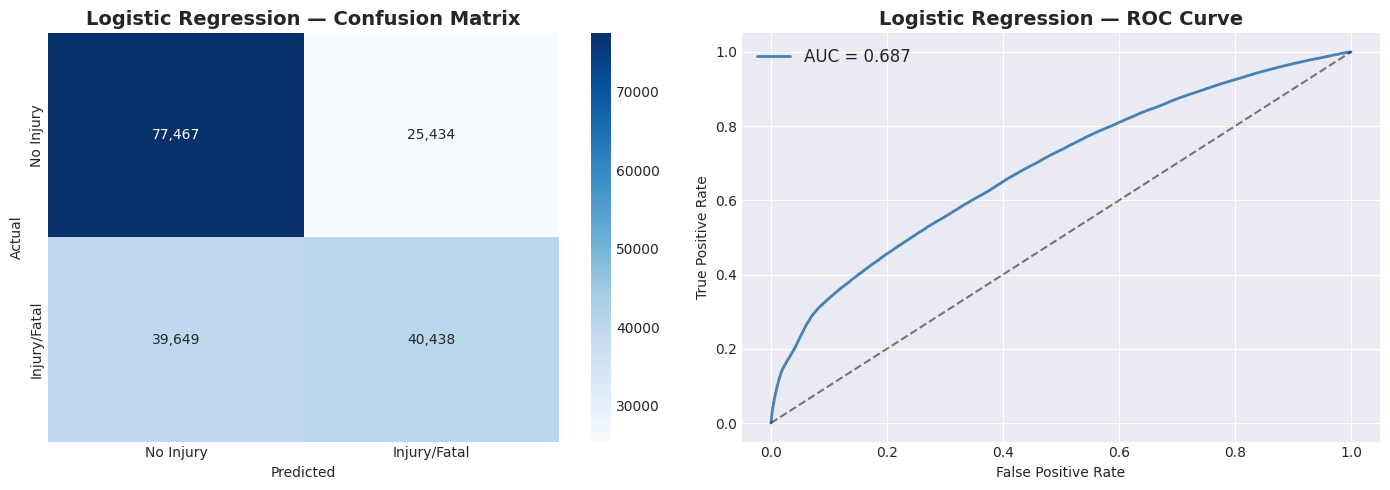

ROC AUC Score: 0.687


In [9]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['No Injury', 'Injury/Fatal'],
            yticklabels=['No Injury', 'Injury/Fatal'])
axes[0].set_title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2, label=f'AUC = {auc_lr:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('Logistic Regression — ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f'ROC AUC Score: {auc_lr:.3f}')

In [11]:
# Aggregate collision counts by borough, day_of_week, hour, month
df_for_counts = df.dropna(subset=['BOROUGH', 'hour']).copy()

collision_counts = df_for_counts.groupby(
    ['BOROUGH', 'day_of_week', 'hour', 'month', 'is_weekend', 'year']
).agg(
    collision_count=('severity', 'count'),
    injury_count=('target_severity', 'sum')
).reset_index()

print(f'Aggregated dataset: {len(collision_counts):,} location-time groups')
print(f'\nCollision count statistics:')
print(collision_counts['collision_count'].describe())

Aggregated dataset: 45,144 location-time groups

Collision count statistics:
count    45144.000000
mean         8.307306
std          6.128102
min          1.000000
25%          3.000000
50%          7.000000
75%         12.000000
max         51.000000
Name: collision_count, dtype: float64


In [12]:
# Prepare Poisson Regression features
poisson_df = pd.get_dummies(collision_counts, columns=['BOROUGH'], drop_first=True)

poisson_features = [c for c in poisson_df.columns if c not in ['collision_count', 'injury_count']]

X_poisson = poisson_df[poisson_features].astype(float)
y_poisson = poisson_df['collision_count']

# Split by year (train: 2022-2023, test: 2024+)
train_mask = poisson_df['year'] < 2024
X_poisson_train = X_poisson[train_mask]
X_poisson_test = X_poisson[~train_mask]
y_poisson_train = y_poisson[train_mask]
y_poisson_test = y_poisson[~train_mask]

print(f'Poisson train: {len(X_poisson_train):,} groups')
print(f'Poisson test:  {len(X_poisson_test):,} groups')

Poisson train: 21,664 groups
Poisson test:  23,480 groups


In [13]:
# Fit Poisson Regression using statsmodels
X_poisson_train_const = sm.add_constant(X_poisson_train)
X_poisson_test_const = sm.add_constant(X_poisson_test)

poisson_model = sm.GLM(
    y_poisson_train,
    X_poisson_train_const,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        collision_count   No. Observations:                21664
Model:                            GLM   Df Residuals:                    21653
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -63839.
Date:                Mon, 02 Mar 2026   Deviance:                       46920.
Time:                        00:20:58   Pearson chi2:                 4.65e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9271
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   145.52

In [14]:
# Poisson predictions and evaluation
y_pred_poisson = poisson_model.predict(X_poisson_test_const)

# Evaluation metrics for count prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_poisson_test, y_pred_poisson)
rmse = np.sqrt(mean_squared_error(y_poisson_test, y_pred_poisson))
mean_actual = y_poisson_test.mean()

print('=' * 60)
print('POISSON REGRESSION — EVALUATION')
print('=' * 60)
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean actual collision count: {mean_actual:.2f}')
print(f'MAE as % of mean: {mae/mean_actual*100:.1f}%')

POISSON REGRESSION — EVALUATION
Mean Absolute Error (MAE): 3.47
Root Mean Squared Error (RMSE): 4.68
Mean actual collision count: 7.79
MAE as % of mean: 44.6%


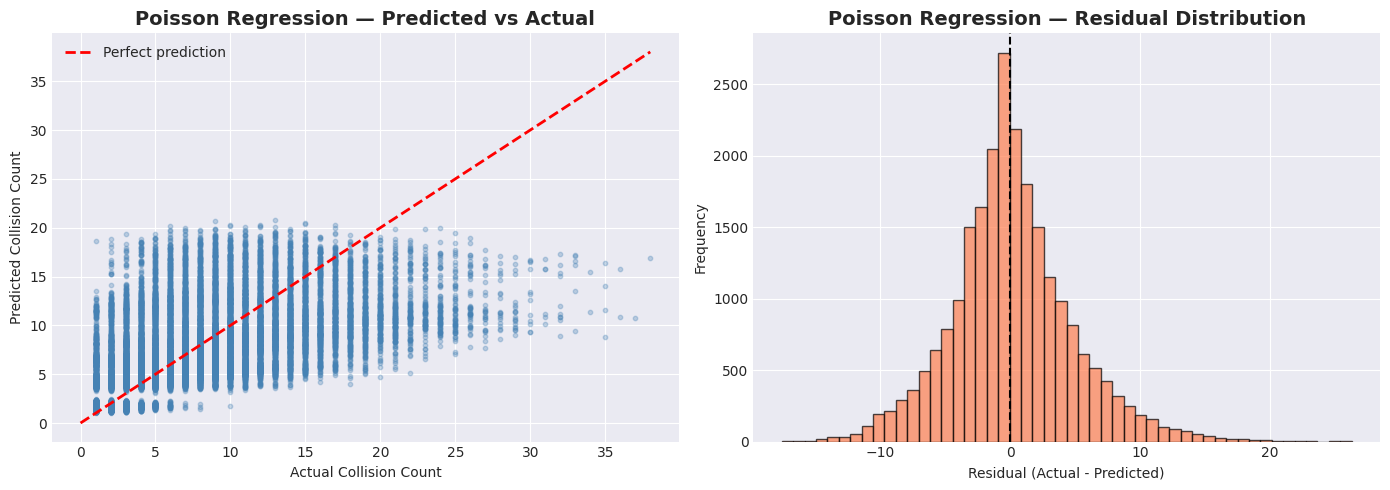

In [15]:
# Visualize Poisson predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predicted vs actual
axes[0].scatter(y_poisson_test, y_pred_poisson, alpha=0.3, s=10, color='steelblue')
max_val = max(y_poisson_test.max(), y_pred_poisson.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Poisson Regression — Predicted vs Actual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Collision Count')
axes[0].set_ylabel('Predicted Collision Count')
axes[0].legend()

# Residuals distribution
residuals = y_poisson_test - y_pred_poisson
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Poisson Regression — Residual Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [16]:
# Naive baseline: always predict majority class
majority_class = y_test.mode()[0]
y_naive = np.full(len(y_test), majority_class)

print('=' * 60)
print('BASELINE METRICS COMPARISON')
print('=' * 60)

metrics = {
    'Model': ['Naive (majority class)', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_naive),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision (Injury)': [
        precision_score(y_test, y_naive, zero_division=0),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall (Injury)': [
        recall_score(y_test, y_naive, zero_division=0),
        recall_score(y_test, y_pred_lr)
    ],
    'F1 (Injury)': [
        f1_score(y_test, y_naive, zero_division=0),
        f1_score(y_test, y_pred_lr)
    ],
    'ROC AUC': [
        0.500,
        roc_auc_score(y_test, y_prob_lr)
    ]
}

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.round(3)
print(metrics_df.to_string(index=False))

BASELINE METRICS COMPARISON
                 Model  Accuracy  Precision (Injury)  Recall (Injury)  F1 (Injury)  ROC AUC
Naive (majority class)     0.562               0.000            0.000        0.000    0.500
   Logistic Regression     0.644               0.614            0.505        0.554    0.687


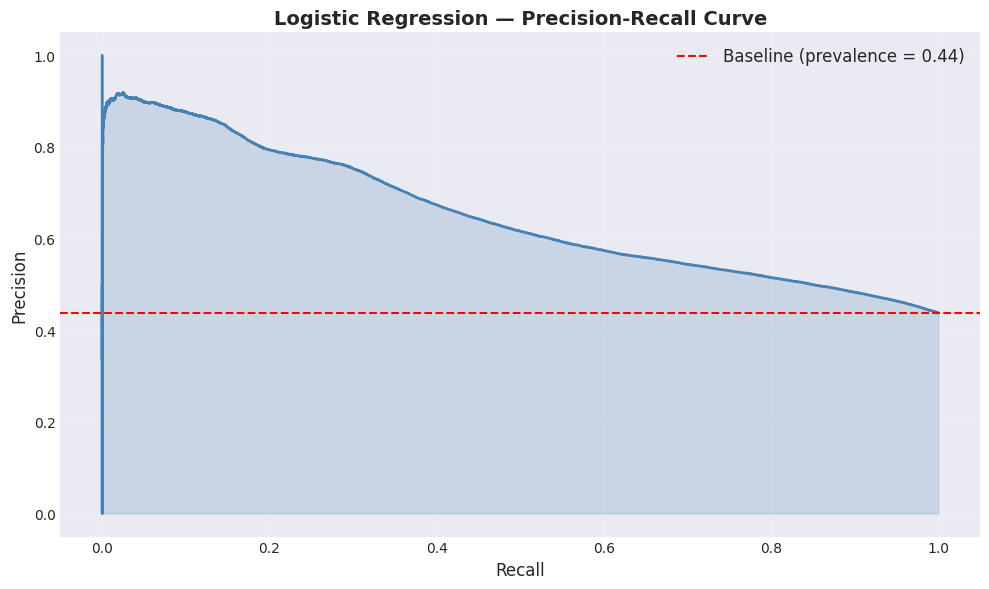

In [17]:
# Precision-Recall Curve (important for imbalanced data)
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', linewidth=2)
plt.fill_between(recall_vals, precision_vals, alpha=0.2, color='steelblue')
plt.title('Logistic Regression — Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Baseline (prevalence = {y_test.mean():.2f})')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Metrics by borough (ensure model generalizes across NYC)
test_with_preds = test_df[['CRASH DATE']].copy()
test_with_preds['BOROUGH'] = df.loc[test_df.index, 'BOROUGH']
test_with_preds['actual'] = y_test.values
test_with_preds['predicted'] = y_pred_lr

print('=' * 60)
print('PERFORMANCE BY BOROUGH')
print('=' * 60)

for borough in sorted(test_with_preds['BOROUGH'].unique()):
    if borough == 'Unknown':
        continue
    mask = test_with_preds['BOROUGH'] == borough
    if mask.sum() < 100:
        continue
    b_actual = test_with_preds.loc[mask, 'actual']
    b_pred = test_with_preds.loc[mask, 'predicted']
    print(f'\n{borough}:')
    print(f'  Records: {mask.sum():,}')
    print(f'  Precision: {precision_score(b_actual, b_pred):.3f}')
    print(f'  Recall:    {recall_score(b_actual, b_pred):.3f}')
    print(f'  F1:        {f1_score(b_actual, b_pred):.3f}')

PERFORMANCE BY BOROUGH

BRONX:
  Records: 21,057
  Precision: 0.651
  Recall:    0.464
  F1:        0.542

BROOKLYN:
  Records: 48,807
  Precision: 0.618
  Recall:    0.515
  F1:        0.562

MANHATTAN:
  Records: 25,982
  Precision: 0.672
  Recall:    0.481
  F1:        0.561

QUEENS:
  Records: 36,994
  Precision: 0.637
  Recall:    0.488
  F1:        0.553

STATEN ISLAND:
  Records: 5,684
  Precision: 0.585
  Recall:    0.371
  F1:        0.454


In [19]:
# Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=' * 60)
print('TOP 20 FEATURES BY ABSOLUTE COEFFICIENT (Logistic Regression)')
print('=' * 60)
print(coef_df.head(20).to_string(index=False))

TOP 20 FEATURES BY ABSOLUTE COEFFICIENT (Logistic Regression)
                                  Feature  Coefficient
                 vehicle_type_clean_Sedan    -1.225440
     vehicle_type_clean_SUV/Station Wagon    -1.161975
         factor_category_Failure to Yield     0.525418
                 vehicle_type_clean_Truck    -0.483168
       factor_category_Distracted Driving     0.411143
                 vehicle_type_clean_Other    -0.409236
          vehicle_type_clean_Pickup Truck    -0.382720
                   vehicle_type_clean_Bus    -0.352395
     vehicle_type_clean_Emergency Vehicle    -0.318594
                  vehicle_type_clean_Taxi    -0.302091
factor_category_Traffic Control Violation     0.298392
 factor_category_Pedestrian/Cyclist Error     0.283598
                  factor_category_Unknown     0.263565
    factor_category_Following Too Closely     0.235185
                 factor_category_Speeding     0.213669
                    factor_category_Other     0.183256
   

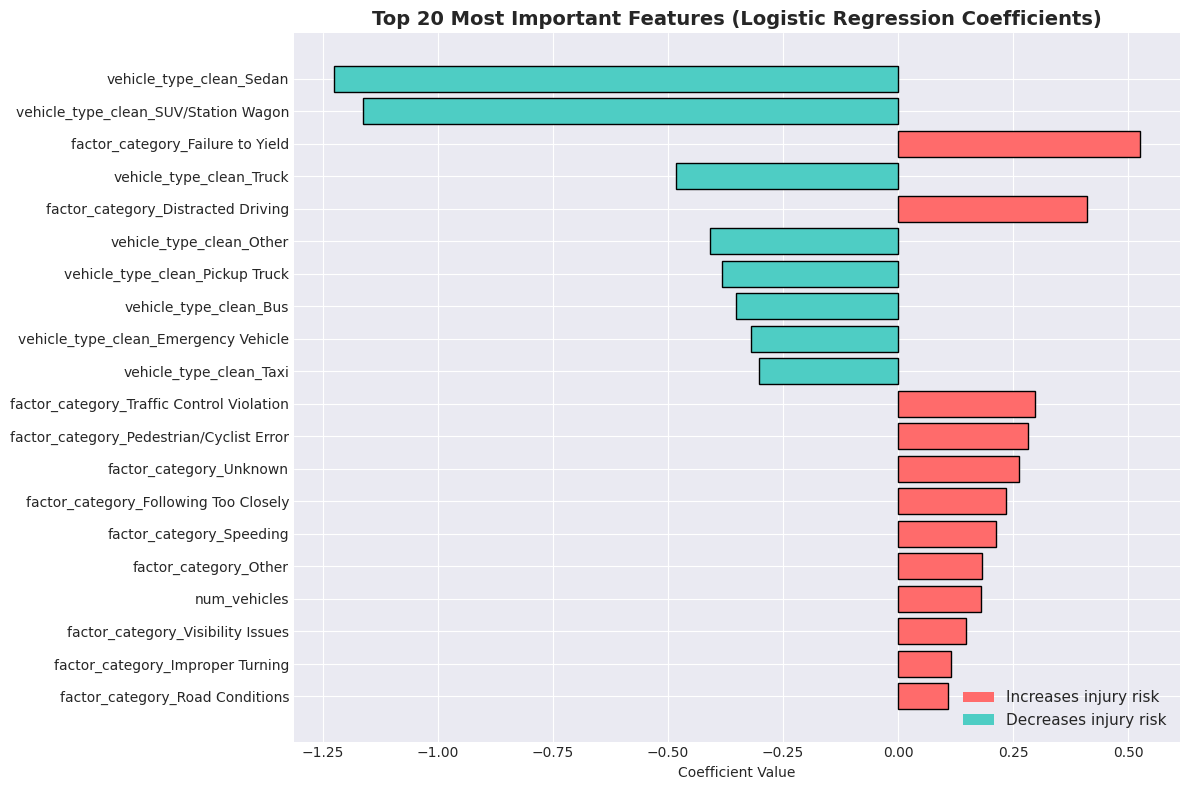

In [20]:
# Visualize top features
top_n = 20
top_features = coef_df.head(top_n).copy()

plt.figure(figsize=(12, 8))
colors = ['#FF6B6B' if c > 0 else '#4ECDC4' for c in top_features['Coefficient']]
plt.barh(range(top_n), top_features['Coefficient'].values, color=colors, edgecolor='black')
plt.yticks(range(top_n), top_features['Feature'].values)
plt.title(f'Top {top_n} Most Important Features (Logistic Regression Coefficients)',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='Increases injury risk'),
    Patch(facecolor='#4ECDC4', label='Decreases injury risk')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Poisson Regression — feature importance
poisson_coefs = pd.DataFrame({
    'Feature': ['const'] + list(X_poisson_train.columns),
    'Coefficient': poisson_model.params.values,
    'P-value': poisson_model.pvalues.values
}).sort_values('Coefficient', key=abs, ascending=False)

print('=' * 60)
print('POISSON REGRESSION — SIGNIFICANT FEATURES')
print('=' * 60)
significant = poisson_coefs[poisson_coefs['P-value'] < 0.05]
print(significant.to_string(index=False))

POISSON REGRESSION — SIGNIFICANT FEATURES
              Feature  Coefficient      P-value
                const   145.521074 1.073373e-55
BOROUGH_STATEN ISLAND    -1.098908 0.000000e+00
      BOROUGH_Unknown     1.041511 0.000000e+00
     BOROUGH_BROOKLYN     0.693447 0.000000e+00
       BOROUGH_QUEENS     0.448213 0.000000e+00
           is_weekend    -0.130280 5.157247e-57
                 year    -0.071258 1.148472e-54
    BOROUGH_MANHATTAN     0.059194 3.975671e-10
                 hour     0.023479 0.000000e+00
          day_of_week     0.021997 1.421211e-32
                month     0.005676 1.898439e-16


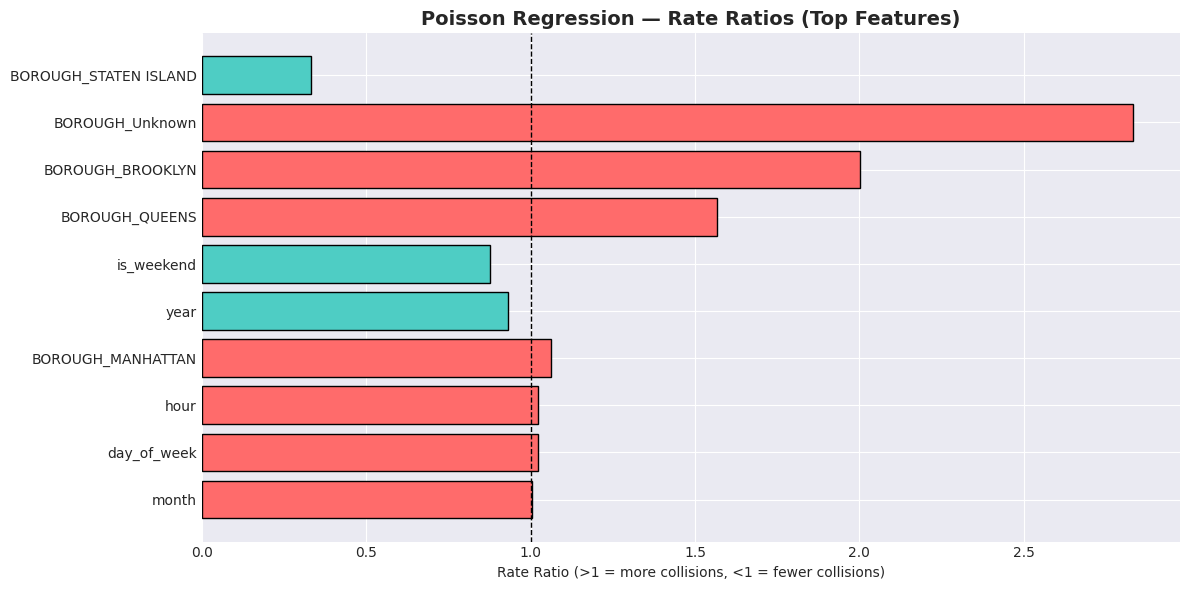

In [22]:
# Visualize Poisson coefficients (as rate ratios for interpretability)
poisson_coefs_clean = poisson_coefs[poisson_coefs['Feature'] != 'const'].copy()
poisson_coefs_clean['Rate Ratio'] = np.exp(poisson_coefs_clean['Coefficient'])

top_poisson = poisson_coefs_clean.head(15)

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B' if rr > 1 else '#4ECDC4' for rr in top_poisson['Rate Ratio']]
plt.barh(range(len(top_poisson)), top_poisson['Rate Ratio'].values, color=colors, edgecolor='black')
plt.yticks(range(len(top_poisson)), top_poisson['Feature'].values)
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)
plt.title('Poisson Regression — Rate Ratios (Top Features)', fontsize=14, fontweight='bold')
plt.xlabel('Rate Ratio (>1 = more collisions, <1 = fewer collisions)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
print('=' * 60)
print('MILESTONE 4 — BASELINE MODELING SUMMARY')
print('=' * 60)

print(f'''
Models Implemented:
  1. Logistic Regression (severity prediction — binary classification)
  2. Poisson Regression (collision count prediction)

Logistic Regression Results:
  - Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.1f}%
  - Precision (Injury/Fatal): {precision_score(y_test, y_pred_lr):.3f}
  - Recall (Injury/Fatal): {recall_score(y_test, y_pred_lr):.3f}
  - F1 Score (Injury/Fatal): {f1_score(y_test, y_pred_lr):.3f}
  - ROC AUC: {roc_auc_score(y_test, y_prob_lr):.3f}

Poisson Regression Results:
  - MAE: {mae:.2f}
  - RMSE: {rmse:.2f}

Key Findings:
  - class_weight='balanced' helps address the class imbalance
  - Contributing factors and vehicle types are strong predictors
  - Performance varies across boroughs — model generalizes but with differences
  - Temporal features (hour, weekend) are significant predictors

Next Steps (Milestone 5):
  - Implement Random Forest and XGBoost for comparison
  - Apply SMOTE/ADASYN for additional imbalance handling
  - Hyperparameter tuning via cross-validation
  - Explore LSTM for temporal modeling (per instructor feedback)
''')

MILESTONE 4 — BASELINE MODELING SUMMARY

Models Implemented:
  1. Logistic Regression (severity prediction — binary classification)
  2. Poisson Regression (collision count prediction)

Logistic Regression Results:
  - Accuracy: 64.4%
  - Precision (Injury/Fatal): 0.614
  - Recall (Injury/Fatal): 0.505
  - F1 Score (Injury/Fatal): 0.554
  - ROC AUC: 0.687

Poisson Regression Results:
  - MAE: 3.47
  - RMSE: 4.68

Key Findings:
  - class_weight='balanced' helps address the class imbalance
  - Contributing factors and vehicle types are strong predictors
  - Performance varies across boroughs — model generalizes but with differences
  - Temporal features (hour, weekend) are significant predictors

Next Steps (Milestone 5):
  - Implement Random Forest and XGBoost for comparison
  - Apply SMOTE/ADASYN for additional imbalance handling
  - Hyperparameter tuning via cross-validation
  - Explore LSTM for temporal modeling (per instructor feedback)

